<p align="center">
  <img src="../assets/prodinno_logo.png" alt="Prodinno" width="200">
</p>

<h4 align="center">Session 1 · Linear & Logistic Regression</h4>
<h1 align="center">Logistic Regression — Breast Cancer Diagnosis</h1>
<p align="center"><i>Notebook 2 — Encoding, scaling, splitting, and correctly balancing the training data</i></p>

---

## 1. From EDA to a Model-Ready Table

Notebook 1 gave us confidence that the 30 features carry real separating signal. Before any
of that signal reaches a logistic regression model, we need to:

1. **Encode** the text target `diagnosis` into a numeric 0/1 label.
2. **Scale** all 30 features so they live on a comparable numeric range.
3. **Split** into train/test, preserving class balance in both (stratified split).
4. **Balance the training split only**, using SMOTE (recap from Notebook 0), while leaving
   the test split at its natural, untouched imbalance.

Each step matters, and the *order* of these steps matters just as much — get it wrong (e.g.
scale before splitting, or SMOTE before splitting) and you leak information from the test set
into training.

In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

RANDOM_STATE = 42
pd.set_option("display.max_columns", 40)

df = pd.read_csv("data/breast_cancer_clean.csv")
print(df.shape)
df.head(3)

(569, 31)


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave_points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst,diagnosis
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,malignant
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,malignant
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,malignant


## 2. Encoding the Target

Logistic regression (and every scikit-learn classifier) expects a numeric target. We map
`malignant -> 1` and `benign -> 0`. Choosing malignant as the **positive class (1)** is a
deliberate convention: in a diagnostic setting, the positive class should be the outcome we
most care about detecting, since precision/recall/F1 are all defined relative to which class
is "positive." 

In [2]:
df["target"] = df["diagnosis"].map({"benign": 0, "malignant": 1})
feature_cols = [c for c in df.columns if c not in ("diagnosis", "target")]

print(f"{len(feature_cols)} feature columns")
df[["diagnosis", "target"]].value_counts()

30 feature columns


diagnosis  target
benign     0         357
malignant  1         212
Name: count, dtype: int64

## 3. Feature Scaling — Why It Matters a Lot Here

Look back at the `.describe()` table from Notebook 0: `area_mean` ranges into the
**thousands**, while `smoothness_mean` lives around **0.05–0.16**. Two distinct reasons this
matters specifically for logistic regression, more so than for tree-based models:

1. **Gradient descent convergence.** Logistic regression is fit by minimizing the log-loss
   with gradient-based optimization (Notebook 3 covers the exact update rule). When features
   live on wildly different scales, the loss surface becomes a long, thin, poorly-conditioned
   ellipse in weight-space — gradient descent zig-zags and converges slowly, or requires many
   more iterations to reach the optimum.
2. **Coefficient interpretability.** A logistic regression coefficient $\theta_j$
   represents the change in log-odds per one-unit increase in feature $j$. If `area_mean`
   (scale: thousands) and `smoothness_mean` (scale: hundredths) are left unscaled, their raw
   coefficients are not comparable — a small coefficient on `area_mean` might still dominate
   the prediction, while a large coefficient on `smoothness_mean` might barely matter. After
   standardizing every feature to zero mean and unit variance, coefficient *magnitude* becomes
   a fair proxy for feature importance.

**Tree-based models (Notebook 3 onward in other sessions) don't need this** — a decision
tree split on `area_mean > 500` is scale-invariant; it only cares about the *ordering* of
values, not their magnitude. Logistic regression's linear-plus-sigmoid form cares about
magnitude directly, which is why scaling is essential here.

We use `StandardScaler`:

$$x' = \frac{x - \mu}{\sigma}$$

> **Leakage rule:** the scaler must be **fit on the training data only**, then used to
> *transform* both train and test. Fitting on the full dataset (including test) would let
> the test set's mean/variance influence the scaling applied to training data — a subtle but
> real form of leakage.

## 4. Stratified Train/Test Split

We split 80/20, using `stratify=target` so both splits preserve the original ~63%/37%
benign/malignant ratio — this is what makes the test set a fair, representative sample of
the deployment distribution.

In [3]:
X = df[feature_cols]
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print("Train class balance:")
print(y_train.value_counts(normalize=True).rename({0: "benign", 1: "malignant"}))
print("\nTest class balance:")
print(y_test.value_counts(normalize=True).rename({0: "benign", 1: "malignant"}))
print(f"\nTrain size: {len(X_train)}, Test size: {len(X_test)}")

Train class balance:
target
benign       0.626374
malignant    0.373626
Name: proportion, dtype: float64

Test class balance:
target
benign       0.631579
malignant    0.368421
Name: proportion, dtype: float64

Train size: 455, Test size: 114


In [4]:
# Fit the scaler on TRAINING data only, then transform both splits
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=feature_cols, index=X_test.index)

X_train_scaled.describe().T[["mean", "std"]].head(6)

,mean,std
radius_mean,-1.737316e-16,1.001101
texture_mean,3.904081e-16,1.001101
perimeter_mean,4.704418e-16,1.001101
area_mean,-1.171224e-16,1.001101
smoothness_mean,7.242070e-16,1.001101
compactness_mean,-5.075305e-17,1.001101


Note the training features now have mean ≈ 0 and std ≈ 1, as expected. The test set
features (below) are close to, but **not exactly**, mean 0 / std 1 — that's expected and
correct, since the scaler's mean/std came from training data, not test data.

In [5]:
X_test_scaled.describe().T[["mean", "std"]].head(6)

,mean,std
radius_mean,-0.054148,0.924651
texture_mean,-0.149115,1.008734
perimeter_mean,-0.049899,0.916549
area_mean,-0.065009,0.879050
smoothness_mean,0.128268,0.909057
compactness_mean,0.046911,0.897930


## 5. Saving the Imbalanced (Pre-SMOTE) Training Set

Before balancing, we save the scaled-but-still-naturally-imbalanced training set. This will
let Notebook 3 train a model on it directly, so we can compare "no fix" vs. "SMOTE fix" on
identical, otherwise-matched data.

In [6]:
train_imbalanced = X_train_scaled.copy()
train_imbalanced["target"] = y_train.values
train_imbalanced.to_csv("data/breast_cancer_processed_train_imbalanced.csv", index=False)

print(train_imbalanced["target"].value_counts().rename({0: "benign", 1: "malignant"}))
train_imbalanced.shape

target
benign       285
malignant    170
Name: count, dtype: int64


(455, 31)

## 6. Balancing the Training Split with SMOTE

Recall from Notebook 0: `class_weight="balanced"` and SMOTE are both valid, non-destructive
fixes for imbalance. Here we apply **SMOTE**, and only to the training split — exactly the
rule established earlier: SMOTE must never touch the test set, because doing so would let
synthetic-neighbor information leak into evaluation, and the test set would no longer purely
reflect the real, deployment-representative distribution.

In [7]:
smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("Training class balance BEFORE SMOTE:")
print(y_train.value_counts().rename({0: "benign", 1: "malignant"}))
print("\nTraining class balance AFTER SMOTE:")
print(y_train_smote.value_counts().rename({0: "benign", 1: "malignant"}))
print(f"\nTraining rows: {len(y_train)} -> {len(y_train_smote)} (synthetic minority rows added)")

Training class balance BEFORE SMOTE:
target
benign       285
malignant    170
Name: count, dtype: int64

Training class balance AFTER SMOTE:
target
malignant    285
benign       285
Name: count, dtype: int64

Training rows: 455 -> 570 (synthetic minority rows added)


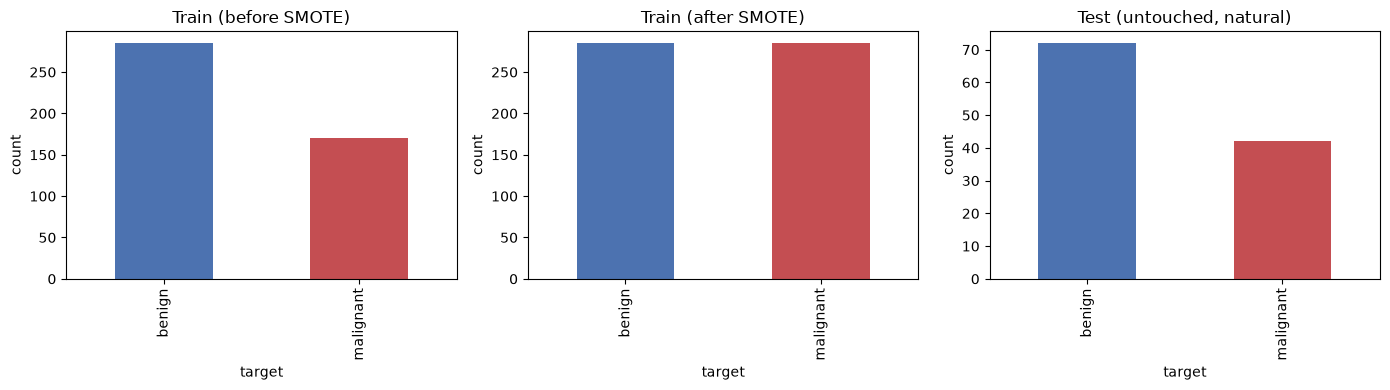

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, counts, title in zip(
    axes,
    [y_train.value_counts(), y_train_smote.value_counts(), y_test.value_counts()],
    ["Train (before SMOTE)", "Train (after SMOTE)", "Test (untouched, natural)"],
):
    counts.rename({0: "benign", 1: "malignant"}).reindex(["benign", "malignant"]).plot(
        kind="bar", ax=ax, color=["#4C72B0", "#C44E52"]
    )
    ax.set_title(title)
    ax.set_ylabel("count")

plt.tight_layout()
plt.show()

The test set (rightmost bar chart) deliberately keeps its natural imbalance — this is
correct and intentional. **Evaluation must reflect the real-world distribution the model
will face in deployment.** Balancing the test set would make evaluation metrics look
different from what the model will actually experience in production.

## 7. Saving the Processed Datasets

We save three files for Notebook 3 to consume:

- `breast_cancer_processed_train.csv` — the **SMOTE-balanced** training set (scaled
  features + target).
- `breast_cancer_processed_test.csv` — the **untouched, naturally-imbalanced** test set
  (scaled features + target).
- `breast_cancer_processed_train_imbalanced.csv` — the **pre-SMOTE** scaled training set
  (already saved above), kept available so Notebook 3 can train a "no fix" comparison
  model on the exact same rows minus the synthetic ones.

In [9]:
train_smote_df = X_train_smote.copy()
train_smote_df["target"] = y_train_smote.values
train_smote_df.to_csv("data/breast_cancer_processed_train.csv", index=False)

test_df = X_test_scaled.copy()
test_df["target"] = y_test.values
test_df.to_csv("data/breast_cancer_processed_test.csv", index=False)

print("Saved:")
print(f"  breast_cancer_processed_train.csv             shape={train_smote_df.shape}")
print(f"  breast_cancer_processed_test.csv               shape={test_df.shape}")
print(f"  breast_cancer_processed_train_imbalanced.csv   shape={train_imbalanced.shape}")

Saved:
  breast_cancer_processed_train.csv             shape=(570, 31)
  breast_cancer_processed_test.csv               shape=(114, 31)
  breast_cancer_processed_train_imbalanced.csv   shape=(455, 31)


## Summary

- Encoded `diagnosis` to a numeric `target` (`malignant = 1`, `benign = 0`).
- Standardized all 30 features — critical for logistic regression's gradient-based fitting
  and for keeping coefficients comparable across features of very different raw scales.
- Split 80/20 with stratification, so both splits preserve the natural ~63%/37% balance.
- Fit the scaler on the training split only, to avoid leaking test-set statistics.
- Applied SMOTE to the training split only; the test split is saved untouched and
  imbalanced, exactly as it will be in deployment.
- Saved three CSVs — SMOTE-balanced train, imbalanced train, and untouched test — so
  Notebook 3 can train and directly compare a "no fix" model against a "SMOTE fix" model on
  identical evaluation data.